In [1]:
import numpy as np
import matplotlib.pyplot as plt

w=0.9135, b=-4.6490
Decision boundary: x = 5.09 hours


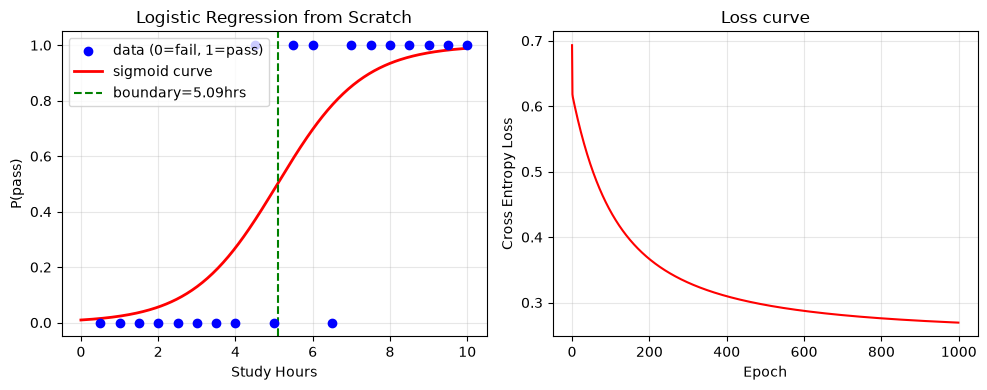

In [2]:
# Cell 2 — Version 1: pass/fail based on study hours
# 1D logistic regression from scratch

X = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5,
              5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10], dtype=float)
y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
              1, 1, 0, 1, 1, 1, 1, 1, 1, 1], dtype=float)

def sigmoid(z): return 1 / (1 + np.exp(-z))

w, b = 0.0, 0.0
lr = 0.1
epochs = 1000
losses = []

for epoch in range(epochs):
    z      = w * X + b
    y_pred = sigmoid(z)
    loss   = -np.mean(y * np.log(y_pred + 1e-9) +
                      (1-y) * np.log(1 - y_pred + 1e-9))
    losses.append(loss)

    dw = np.mean((y_pred - y) * X)
    db = np.mean(y_pred - y)
    w -= lr * dw
    b -= lr * db

print(f"w={w:.4f}, b={b:.4f}")
print(f"Decision boundary: x = {-b/w:.2f} hours")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
x_range = np.linspace(0, 10, 300)
plt.scatter(X, y, color='blue', zorder=5, label='data (0=fail, 1=pass)')
plt.plot(x_range, sigmoid(w*x_range + b), 'r-', linewidth=2, label='sigmoid curve')
plt.axvline(-b/w, color='green', linestyle='--', label=f'boundary={-b/w:.2f}hrs')
plt.xlabel('Study Hours'); plt.ylabel('P(pass)')
plt.title('Logistic Regression from Scratch'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(losses, 'r-')
plt.xlabel('Epoch'); plt.ylabel('Cross Entropy Loss')
plt.title('Loss curve'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

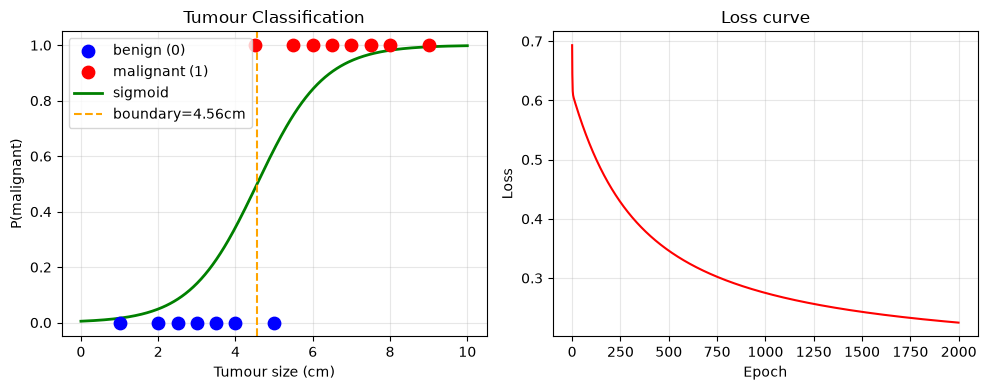

In [3]:
# Cell 3 — Version 2: tumour size vs malignant (classic example)
X = np.array([1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6,
              6.5, 7, 7.5, 8, 9], dtype=float)
y = np.array([0, 0, 0,   0, 0,   0, 1,   0, 1,   1,
              1,  1, 1,   1, 1],  dtype=float)

def sigmoid(z): return 1 / (1 + np.exp(-z))

w, b = 0.0, 0.0
lr = 0.05
losses = []

for _ in range(2000):
    y_pred = sigmoid(w*X + b)
    loss   = -np.mean(y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9))
    losses.append(loss)
    dw = np.mean((y_pred - y) * X)
    db = np.mean(y_pred - y)
    w -= lr*dw; b -= lr*db

x_range = np.linspace(0, 10, 300)
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.scatter(X[y==0], y[y==0], color='blue',  s=80, label='benign (0)', zorder=5)
plt.scatter(X[y==1], y[y==1], color='red',   s=80, label='malignant (1)', zorder=5)
plt.plot(x_range, sigmoid(w*x_range + b), 'g-', linewidth=2, label='sigmoid')
plt.axvline(-b/w, color='orange', linestyle='--', label=f'boundary={-b/w:.2f}cm')
plt.xlabel('Tumour size (cm)'); plt.ylabel('P(malignant)')
plt.title('Tumour Classification'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(losses, 'r-')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss curve')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

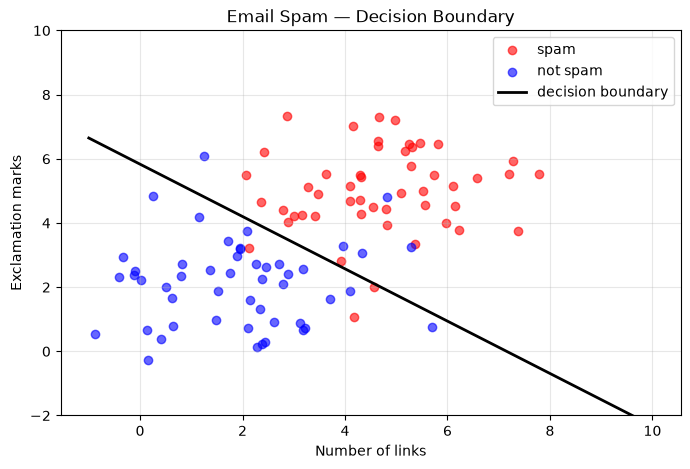

Accuracy: 92.0%


In [4]:
# Cell 4 — Version 3: email spam detection (2 features)
np.random.seed(42)
# feature 1: number of links, feature 2: number of exclamation marks
X_spam    = np.column_stack([np.random.randn(50)*1.5 + 5,
                              np.random.randn(50)*1.5 + 5])   # spam
X_notspam = np.column_stack([np.random.randn(50)*1.5 + 2,
                              np.random.randn(50)*1.5 + 2])   # not spam

X = np.vstack([X_spam, X_notspam])
y = np.array([1]*50 + [0]*50, dtype=float)

def sigmoid(z): return 1 / (1 + np.exp(-z))

w = np.zeros(2); b = 0.0
lr = 0.05; losses = []

for _ in range(1000):
    z      = X @ w + b
    y_pred = sigmoid(z)
    loss   = -np.mean(y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9))
    losses.append(loss)
    dw = X.T @ (y_pred - y) / len(y)
    db = np.mean(y_pred - y)
    w -= lr*dw; b -= lr*db

# decision boundary: w0*x1 + w1*x2 + b = 0 → x2 = (-w0*x1 - b) / w1
x1_range = np.linspace(-1, 10, 300)
x2_boundary = (-w[0]*x1_range - b) / w[1]

plt.figure(figsize=(8, 5))
plt.scatter(X_spam[:,0],    X_spam[:,1],    c='red',  alpha=0.6, label='spam')
plt.scatter(X_notspam[:,0], X_notspam[:,1], c='blue', alpha=0.6, label='not spam')
plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='decision boundary')
plt.xlabel('Number of links'); plt.ylabel('Exclamation marks')
plt.title('Email Spam — Decision Boundary'); plt.legend()
plt.ylim(-2, 10); plt.grid(True, alpha=0.3); plt.show()

acc = np.mean((sigmoid(X @ w + b) >= 0.5) == y)
print(f"Accuracy: {acc*100:.1f}%")

TP=4 TN=3 FP=2 FN=1
Accuracy  = 0.70
Precision = 0.67
Recall    = 0.80


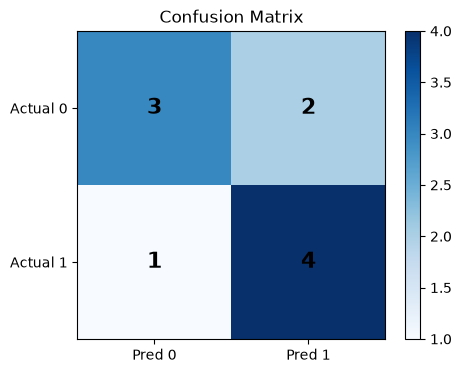

In [5]:
# Cell 5 — Version 4: predictions + confusion matrix manually
y_actual = np.array([1,1,1,1,0,0,0,0,1,0])
y_prob   = np.array([0.9,0.8,0.7,0.4,0.3,0.2,0.6,0.1,0.85,0.55])
threshold = 0.5
y_pred   = (y_prob >= threshold).astype(int)

TP = np.sum((y_pred==1) & (y_actual==1))
TN = np.sum((y_pred==0) & (y_actual==0))
FP = np.sum((y_pred==1) & (y_actual==0))
FN = np.sum((y_pred==0) & (y_actual==1))

accuracy  = (TP+TN) / len(y_actual)
precision = TP / (TP+FP) if (TP+FP)>0 else 0
recall    = TP / (TP+FN) if (TP+FN)>0 else 0

print(f"TP={TP} TN={TN} FP={FP} FN={FN}")
print(f"Accuracy  = {accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall    = {recall:.2f}")

# visualise confusion matrix
cm = np.array([[TN, FP],[FN, TP]])
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', fontsize=16, fontweight='bold')
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['Actual 0','Actual 1'])
plt.title('Confusion Matrix'); plt.show()